# 120 years of Olympic medalists: finding the story in the data

**Analyst:** Maurice Colbert Jr. · **Stack:** Python, pandas, matplotlib

## The brief

I was given a dataset of every Olympic medal awarded between 1896 and 2016 and a
newsroom-style brief: explore it, then pitch a data-driven story a general audience
would actually read. Unlike a normal analytics request there was no predefined
question, so most of the work was deciding which question was worth asking.

## How I approached it

I ran the standard descriptive pass first (size, types, missingness, distributions),
but I treated that pass as **lead generation** rather than as the deliverable. Every
summary statistic is a candidate story; the interesting ones are the values that do
not fit the pattern I expect. The single number that did that here was the age range:
a 10-year-old and a 73-year-old both won Olympic medals. Chasing that outlier led to
the story I ultimately pitched.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (10, 4.5),
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

medals = pd.read_csv("data/olympics.csv")
print(f"{len(medals):,} medal records | {medals.Year.min()}–{medals.Year.max()} | "
      f"{medals.Games.nunique()} games | {medals.Sport.nunique()} sports | "
      f"{medals.Event.nunique()} events | {medals.region.nunique()} countries")
medals.head()

39,783 medal records | 1896–2016 | 51 games | 66 sports | 756 events | 136 countries


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region
0,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark
1,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze,Finland
2,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze,Finland
3,16,Juhamatti Tapio Aaltonen,M,28.0,184.0,85.0,Finland,FIN,2014 Winter,2014,Winter,Sochi,Ice Hockey,Ice Hockey Men's Ice Hockey,Bronze,Finland
4,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze,Finland


## Data quality: two decisions that shape everything after them

### 1. Missing values are not spread evenly, so era comparisons are dangerous

`Height` and `Weight` have thousands of nulls. The usual reflex is to drop those rows
or fill them with a mean. Before doing either I checked *where* the nulls sit, because
missing-at-random and missing-by-era have completely different consequences.

In [2]:
medals["era"] = pd.cut(medals.Year, [1895, 1936, 1959, 1979, 2016],
                       labels=["1896–1936", "1937–1959", "1960–1979", "1980–2016"])
missing_by_era = (medals.groupby("era", observed=True)[["Age", "Height", "Weight"]]
                  .apply(lambda d: 100 * d.isna().mean())
                  .round(1))
missing_by_era

,Age,Height,Weight
era,,,
1896–1936,8.3,75.4,81.3
1937–1959,1.0,62.7,62.9
1960–1979,0.1,2.0,2.6
1980–2016,0.0,1.7,2.1


The missingness is almost entirely historical: 75% of 1896–1936 records have no
height, against 1.7% after 1980. Early Olympic organizers simply did not record body
measurements.

That rules out a tempting analysis — "athletes have gotten bigger over time" — because
any early-era average would be computed from the small, unrepresentative minority of
athletes who happened to be measured. So I made two rules for the rest of the
analysis:

- Leave the nulls in place (pandas excludes them from aggregations) rather than
  imputing values I cannot justify.
- Only report height and weight **within a single recent Games**, where coverage is
  near-complete, and state the sample size when I do.

### 2. `Team` is not a country column

The dataset has three location-ish columns, so I checked whether they agree before
picking one.

In [3]:
print(f"Unique values — Team: {medals.Team.nunique()}, NOC: {medals.NOC.nunique()}, "
      f"region: {medals.region.nunique()}")
print(f"Team disagrees with region on {100 * (medals.Team != medals.region).mean():.1f}% of rows\n")
print("Examples of what Team actually contains:")
print(medals.loc[medals.Team.str.contains("/", na=False), "Team"].value_counts().head(5).to_string())

Unique values — Team: 498, NOC: 149, region: 136
Team disagrees with region on 37.1% of rows

Examples of what Team actually contains:
Team
Pistoja/Firenze          9
Denmark/Sweden           6
Barion/Bari-2            3
Great Britain/Germany    2
United States/France     2


`Team` holds 498 distinct values against 136 countries, and the extras are club and
city names (`Pistoja/Firenze`), mixed-nationality crews (`Denmark/Sweden`), and
numbered squads (`Bari-2`). Grouping by `Team` would silently split one country's
medals across many labels. I dropped it and standardized on `NOC` / `region`, renamed
so their meaning is obvious to anyone reading the notebook later.

In [4]:
medals = (medals
          .drop(columns=["Team"])
          .rename(columns={"NOC": "CountryCode", "region": "Country"}))

missing_codes = sorted(set(medals.CountryCode[medals.Country.isna()]))
print(f"Rows with no Country: {medals.Country.isna().sum()} (country codes involved: {missing_codes})")
medals.loc[medals.Country.isna(), "Country"] = "Singapore"  # SGP is unambiguous
print(f"Remaining nulls in Country: {medals.Country.isna().sum()}")

Rows with no Country: 9 (country codes involved: ['SGP'])
Remaining nulls in Country: 0


Nine rows had a null country. All nine carry the code `SGP`, which is unambiguously
Singapore, so this is a safe fix rather than a guess — and I would rather repair nine
rows than silently drop them.

## The descriptive pass

This is the lead-generation step: fast, broad, and looking for anything that does not
fit.

In [5]:
summary = pd.Series({
    "Medal records": len(medals),
    "Distinct athletes": medals.ID.nunique(),
    "Sports": medals.Sport.nunique(),
    "Events": medals.Event.nunique(),
    "Countries": medals.Country.nunique(),
    "Youngest medalist": medals.Age.min(),
    "Oldest medalist": medals.Age.max(),
    "Mean age": round(medals.Age.mean(), 1),
})
print(summary.to_string())
print()
print(medals.Medal.value_counts().to_string())

Medal records        39783.0
Distinct athletes    28251.0
Sports                  66.0
Events                 756.0
Countries              137.0
Youngest medalist       10.0
Oldest medalist         73.0
Mean age                25.9

Medal
Gold      13372
Bronze    13295
Silver    13116


Two things stood out.

**Bronze outnumbers silver** (13,295 to 13,116). That is not a data error: in
bracketed sports such as judo, wrestling, and boxing, two bronzes are awarded in some
formats while only one silver exists. Worth knowing so I do not "fix" it.

**The age range is 63 years wide.** A 10-year-old medalist and a 73-year-old medalist
cannot both be explained by the modern picture of an elite athlete. That is the thread
I pulled.

In [6]:
print("Youngest medalists:")
print(medals.nsmallest(3, "Age")[["Name", "Age", "Year", "Sport", "Medal", "Country"]].to_string(index=False))
print("\nTen oldest medalists:")
oldest = medals.nlargest(10, "Age")
print(oldest[["Name", "Age", "Year", "Sport", "Medal", "Country"]].to_string(index=False))
print("\nSports among the ten oldest:")
print(oldest.Sport.value_counts().to_string())

Youngest medalists:
              Name  Age  Year      Sport  Medal Country
Dimitrios Loundras 10.0  1896 Gymnastics Bronze  Greece
  Luigina Giavotti 11.0  1928 Gymnastics Silver   Italy
   Carla Marangoni 12.0  1928 Gymnastics Silver   Italy

Ten oldest medalists:
                                         Name  Age  Year            Sport  Medal     Country
John (Herbert Crawford-) Copley (Williamson-) 73.0  1948 Art Competitions Silver          UK
                                   Jozu Dupon 72.0  1936 Art Competitions Bronze     Belgium
                            Oscar Gomer Swahn 72.0  1920         Shooting Silver      Sweden
                       Charles William Martin 71.0  1900          Sailing Silver      France
                       Charles William Martin 71.0  1900          Sailing Bronze      France
                      Letitia Marion Hamilton 69.0  1948 Art Competitions Bronze     Ireland
                                 Oskar Thiede 69.0  1948 Art Competitions Silver  

## The finding: half of the oldest medalists were not athletes

Five of the ten oldest medalists in Olympic history won their medals in **Art
Competitions**. Sculptors and painters, competing for Olympic medals, in the same
Games as sprinters.

I checked whether this was a handful of curiosities or a real category.

In [7]:
art = medals[medals.Sport == "Art Competitions"]
print(f"Art Competition medals: {len(art)}")
print(f"Years contested:        {[int(y) for y in sorted(art.Year.unique())]}")
print(f"Mean age of medalist:   {art.Age.mean():.1f}  (all sports: {medals.Age.mean():.1f})")
print(f"Share of all medals awarded 1912–1948: {100 * len(art) / len(medals[medals.Year.between(1912, 1948)]):.1f}%")

over_60 = medals[medals.Age >= 60]
print(f"\nMedalists aged 60+: {len(over_60)}")
print(over_60.Sport.value_counts().head(5).to_string())

Art Competition medals: 156
Years contested:        [1912, 1920, 1924, 1928, 1932, 1936, 1948]
Mean age of medalist:   42.3  (all sports: 25.9)
Share of all medals awarded 1912–1948: 2.3%

Medalists aged 60+: 42
Sport
Art Competitions    11
Shooting            11
Archery             11
Sailing              4
Equestrianism        4


So it was a real programme: 156 medals across seven Games from 1912 to 1948, with a
mean medalist age of 42 — sixteen years above the overall average. It then disappeared
completely after 1948.

That reframed the dataset for me. The early Olympics were not a smaller version of the
modern Games; they were a different kind of event, closer to a cultural festival. If
that is true, the shift should show up in more than one measure — so I tested it
against three independent signals.

In [8]:
def by_year_for(season: str) -> pd.DataFrame:
    """Per-Games summary for one season.

    Summer and Winter must be tracked separately. A Winter Games has roughly a
    third as many events as a Summer Games, so combining them into one series
    produces a sawtooth that looks like the programme repeatedly shrinking and
    expanding rather than a trend.
    """
    subset = medals[medals.Season == season]
    return pd.DataFrame({
        "events": subset.groupby("Year").Event.nunique(),
        "countries": subset.groupby("Year").Country.nunique(),
        "female_pct": subset.groupby("Year").apply(
            lambda d: 100 * (d.Sex == "F").mean(), include_groups=False),
    })


summer = by_year_for("Summer")
winter = by_year_for("Winter")
art_by_year = medals[medals.Sport == "Art Competitions"].groupby("Year").size()

print("Summer Games:")
print(summer.loc[[1896, 1912, 1936, 1948, 1960, 1984, 2000, 2016]].round(1).to_string())
print("\nWinter Games:")
print(winter.loc[[1924, 1960, 1984, 2014]].round(1).to_string())

Summer Games:
      events  countries  female_pct
Year                               
1896      43         10         0.0
1912     107         19         3.2
1936     143         32         9.6
1948     148         38        11.9
1960     150         44        17.1
1984     221         47        33.5
2000     300         80        43.9
2016     306         86        47.9

Winter Games:
      events  countries  female_pct
Year                               
1924      17         13         4.6
1960      27         14        26.5
1984      39         16        24.3
2014      98         26        44.4


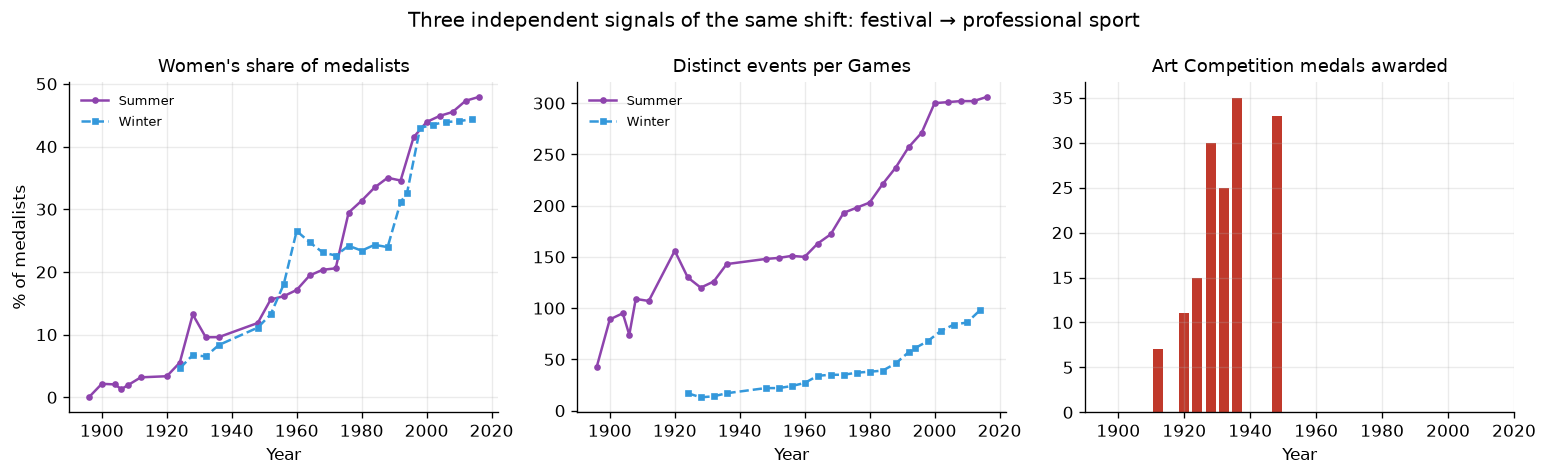

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].plot(summer.index, summer.female_pct, color="#8e44ad", marker="o", markersize=3, label="Summer")
axes[0].plot(winter.index, winter.female_pct, color="#3498db", marker="s", markersize=3,
             linestyle="--", label="Winter")
axes[0].set_title("Women's share of medalists", fontsize=11)
axes[0].set_ylabel("% of medalists")
axes[0].legend(frameon=False, fontsize=8)

axes[1].plot(summer.index, summer.events, color="#8e44ad", marker="o", markersize=3, label="Summer")
axes[1].plot(winter.index, winter.events, color="#3498db", marker="s", markersize=3,
             linestyle="--", label="Winter")
axes[1].set_title("Distinct events per Games", fontsize=11)
axes[1].legend(frameon=False, fontsize=8)

axes[2].bar(art_by_year.index, art_by_year.values, width=3, color="#c0392b")
axes[2].set_title("Art Competition medals awarded", fontsize=11)
axes[2].set_xlim(1890, 2020)

for ax in axes:
    ax.set_xlabel("Year")

fig.suptitle("Three independent signals of the same shift: festival → professional sport", fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES / "01_olympic_transformation.png", bbox_inches="tight")
plt.show()

All three signals agree, which is what makes this a story rather than a coincidence:

- **Art medals** run 1912–1948, then stop permanently.
- **Women's share** of medalists goes from 0% in 1896 to 47.9% at the 2016 Summer Games,
  with the Winter Games following the same trajectory.
- **Events per Summer Games** grow from 43 to 306, and participating countries from 10
  to 86.

Splitting the seasons matters here. My first version of this chart plotted all Games on
one line and produced a sawtooth, because a Winter Games has roughly a third the events
of a Summer Games — it looked like the programme was repeatedly collapsing and recovering
rather than growing steadily.

The Games did not simply get bigger. Their *purpose* changed — from a broad
celebration of culture and physical life into a professionalized, global sporting
competition with near-parity participation.

## Supporting analysis

These are the conventional questions a reporter would ask next, so I answered them
with the cleaned data.

In [10]:
medal_table = (medals.groupby("Country")
               .agg(total=("Medal", "size"),
                    gold=("Medal", lambda s: (s == "Gold").sum()))
               .nlargest(10, "total"))
medal_table["gold_pct"] = (100 * medal_table.gold / medal_table.total).round(1)
medal_table

,total,gold,gold_pct
Country,,,
USA,5637,2638,46.8
Russia,3947,1599,40.5
Germany,3756,1301,34.6
UK,2068,678,32.8
France,1777,501,28.2
Italy,1637,575,35.1
Sweden,1536,479,31.2
Canada,1352,463,34.2
Australia,1349,368,27.3


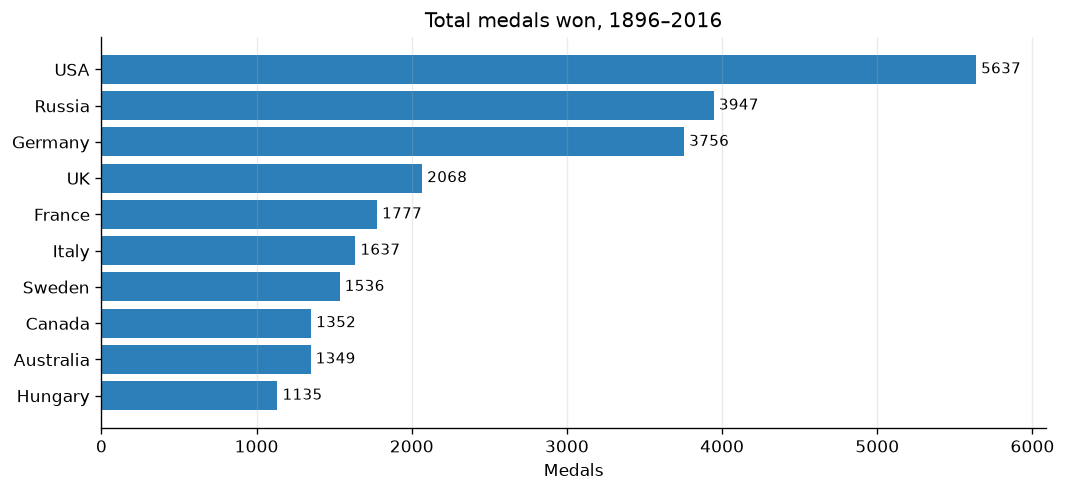

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.2))
top = medal_table.sort_values("total")
ax.barh(top.index, top.total, color="#2c7fb8")
ax.bar_label(ax.containers[0], fmt="%d", padding=3, fontsize=9)
ax.set_title("Total medals won, 1896–2016")
ax.set_xlabel("Medals")
ax.grid(axis="y", visible=False)
ax.margins(x=0.08)
fig.tight_layout()
fig.savefig(FIGURES / "02_medal_table.png", bbox_inches="tight")
plt.show()

In [12]:
# Body measurements: restricted to the most recent Games of each season, where
# coverage is near-complete (see the missingness table above).
def profile(games_label: str) -> pd.Series:
    g = medals[medals.Games == games_label]
    height_cm = g.Height.mean()
    inches = height_cm / 2.54
    return pd.Series({
        "medalists_measured": int(g.Height.notna().sum()),
        "mean_height_cm": round(height_cm, 1),
        "mean_height_ft_in": f"{int(inches // 12)}'{inches % 12:.1f}\"",
        "mean_weight_kg": round(g.Weight.mean(), 1),
        "mean_age": round(g.Age.mean(), 1),
    })


pd.DataFrame({"2016 Summer": profile("2016 Summer"), "2014 Winter": profile("2014 Winter")})

,2016 Summer,2014 Winter
medalists_measured,2020,597
mean_height_cm,178.4,175.4
mean_height_ft_in,"5'10.2""","5'9.0"""
mean_weight_kg,74.0,72.2
mean_age,26.3,26.6


## Story pitch

**Headline angle:** *The Olympics used to give medals for sculpture. What we stopped
rewarding says as much as what we started rewarding.*

**The data that supports it:**

- Olympic medals spanned ages 10 to 73; the top of that range is dominated by artists,
  not athletes (5 of the 10 oldest medalists competed in Art Competitions).
- 156 medals were awarded for art between 1912 and 1948, with a mean medalist age of
  42 against 26 overall. The category was abolished after 1948.
- Over the same period the Games professionalized on every other axis: events 43 →
  306, countries 10 → 85, women 0% → 47.9% of medalists.

**Why a general reader cares:** everyone assumes the Olympics have always been about
athletic performance. They have not. The Games are a record of what each era thought
was worth celebrating, and the disappearance of the art medal is the cleanest evidence
of that change.

**What I would gather next:** the IOC's stated reason for ending the art competitions
(the amateurism rules are the likely cause, since artists sold their work); the year
each replacement cultural programme was introduced; and participation data alongside
medal data, so I can distinguish a growth in *opportunity* from a growth in *access*.

## Limitations

- The dataset contains medal-winning entries only. It cannot speak to participation
  rates, so "women were 47.9% of medalists" is not the same as "47.9% of competitors."
- Team events award one medal per athlete, so team sports are over-weighted in any
  raw medal count, including the country table above.
- Country labels are modern; historical entities such as the USSR and East Germany are
  mapped in ways that make long-run country comparisons imperfect.
- Height and weight are only reliable from about 1960 onward, which is why I confined
  those figures to single recent Games.

## How I used AI on this project

I did the analysis and chose the story angle myself. AI was a copilot in two places:

1. **A second opinion on missing data.** I described the null pattern in `Age`,
   `Height`, and `Weight` and asked whether ignoring them was defensible. The useful
   part of the answer was the reminder to check whether missingness correlates with
   another variable — which is exactly what the era breakdown above tests, and it
   turned out to be the reason I abandoned the cross-era body-size comparison.
2. **Framing the pitch.** I gave the model my findings and asked for ways to frame
   them for a general audience. It suggested leading with the human oddity (a
   73-year-old sculptor) before the structural argument, which I kept. I wrote the
   pitch itself, and I verified every number in it against the notebook.